# What is the most optimal skill to learn for Data Analysts?

**Methodology**
1. Continue from last notebook to find percent of postings with skill
2. Visualize median salary vs percent skill demand
3. Determine if certain technologies are more prevalent

## Import Libraries and Data

In [ ]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Clean Data

Filters the original dataset to only get rows where the job title is 'Data Analyst' and the country is 'United States', to create a new DataFrame df_US. Drop NaN values from the 'salary_year_avg' column. Then it uses the explode method on the job_skills column to create a new row in a new DataFrame (df_US_exploded) for each skill associated with a job. Finally, it displays the first 5 entries of the salary_year_avg and job_skills columns.

In [2]:
df_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country']=='United States')].copy()

df_US = df_US.dropna(subset='salary_year_avg')

df_US_exploded = df_US.explode('job_skills')

df_US_exploded[['salary_year_avg','job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


Calculate Percent of Job Postings that Have Skills

Group the data by job skills and calculates the count and median salary for each skills, sorting the results in descending order by count. It then renames the columns. Calculates the percentage that each skill count represents out of the total number of Data Analyst jobs. Finally, filter out any skills that don't have any jobs associated with them. 

In [3]:
df_skill_stats = df_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_skill_stats = df_skill_stats.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_US)  # Find count of Data Analyst jobs in US with salary info

df_skill_stats['skill_percent'] = df_skill_stats['skill_count'] / DA_job_count * 100

df_skill_stats = df_skill_stats[df_skill_stats['skill_count'] > 0]

df_skill_stats

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
theano,1,100000.0,0.022989
typescript,1,65000.0,0.022989
vmware,1,147500.0,0.022989


## Median Salary vs Percent Skill Demand

Filters for Data Analyst skills that exceed a certain percentage (skill limit)

In [4]:
skill_limit = 5

df_skills_high_demand = df_skill_stats[df_skill_stats['skill_percent'] > skill_limit]

Create a scatter plot to visualize the relationship between the percentage of Data Analyst jobs that require specific skills and the median salary for those skills. 

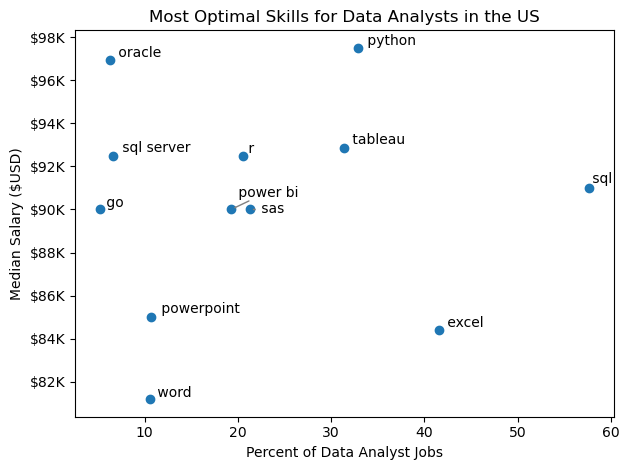

In [5]:
from adjustText import adjust_text

# df_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')
plt.scatter(df_skills_high_demand['skill_percent'], df_skills_high_demand['median_salary'])

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_skills_high_demand.index):
    texts.append(plt.text(df_skills_high_demand['skill_percent'].iloc[i], df_skills_high_demand['median_salary'].iloc[i], " " + txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')
plt.title('Most Optimal Skills for Data Analysts in the US')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis

# Adjust layout and display plot 
plt.tight_layout()
plt.show()


## Additional information: Coloring by technology

This exercise is to add color labels based on technology.

Removes duplicate entries and any rows with missing values. Then, it combines all dictionary entries into a single dictionary, summing values for keys that repeat across entries. To ensure each key's values are unique, it converts the values to a set and then back to a list. The final result is a dictionary where each key represents a skill and each value is a list of unique attributes associated with that skill.

In [6]:
df_technology = df['job_type_skills'].copy()

df_technology = df_technology.drop_duplicates()

df_technology = df_technology.dropna()

technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['tableau',
  'sap',
  'microstrategy',
  'sheets',
  'sharepoint',
  'excel',
  'ms access',
  'alteryx',
  'spss',
  'looker',
  'ssrs',
  'splunk',
  'word',
  'ssis',
  'powerbi',
  'dax',
  'spreadsheet',
  'qlik',
  'sas',
  'visio',
  'nuix',
  'datarobot',
  'msaccess',
  'power bi',
  'esquisse',
  'powerpoint',
  'cognos',
  'outlook'],
 'programming': ['no-sql',
  'haskell',
  'pascal',
  'go',
  'golang',
  'ocaml',
  'vba',
  'ruby',
  'crystal',
  'visual basic',
  'sql',
  'scala',
  'visualbasic',
  'f#',
  'kotlin',
  'c++',
  'cobol',
  'html',
  'assembly',
  'shell',
  't-sql',
  'java',
  'c#',
  'julia',
  'dart',
  'objective-c',
  'vb.net',
  'erlang',
  'powershell',
  'javascript',
  'swift',
  'solidity',
  'matlab',
  'sass',
  'bash',
  'php',
  'sas',
  'lisp',
  'python',
  'groovy',
  'clojure',
  'mongodb',
  'elixir',
  'c',
  'perl',
  'fortran',
  'lua',
  'nosql',
  'css',
  'mongo',
  'apl',
  'typescript',
  'r',
  'delphi',
  'r

This code converts a dictionary into a pandas DataFrame, then explodes the 'skills' column, creating multiple rows for each 'technology' entry if it contains multiple skills.

In [8]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology','skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,tableau
0,analyst_tools,sap
0,analyst_tools,microstrategy
0,analyst_tools,sheets
0,analyst_tools,sharepoint
...,...,...
9,sync,twilio
9,sync,zoom
9,sync,ringcentral
9,sync,rocketchat


Merges two DataFrames, df_skills_stats and df_technology, based on the columns 'job_skills' and 'skills' respectively, creating a new DataFrame df_skills_tech.

In [9]:
df_skill_tech = df_skill_stats.merge(df_technology, left_on='job_skills', right_on='skills')

df_skill_tech

,skill_count,median_salary,skill_percent,technology,skills
0,2508,91000.0,57.655172,programming,sql
1,1808,84392.0,41.563218,analyst_tools,excel
2,1431,97500.0,32.896552,programming,python
3,1364,92875.0,31.356322,analyst_tools,tableau
4,926,90000.0,21.287356,analyst_tools,sas
...,...,...,...,...,...
169,1,100000.0,0.022989,libraries,theano
170,1,65000.0,0.022989,programming,typescript
171,1,147500.0,0.022989,cloud,vmware
172,1,65000.0,0.022989,webframeworks,vue


Filters df_skills_tech to select rows where the 'percent' column exceeds a specified threshold, storing the result in df_skills_tech_high_demand.

In [10]:
df_skills_tech_high_demand = df_skill_tech[df_skill_tech['skill_percent'] > skill_limit]
df_skills_tech_high_demand

,skill_count,median_salary,skill_percent,technology,skills
0,2508,91000.00,57.655172,programming,sql
1,1808,84392.00,41.563218,analyst_tools,excel
2,1431,97500.00,32.896552,programming,python
3,1364,92875.00,31.356322,analyst_tools,tableau
4,926,90000.00,21.287356,analyst_tools,sas
5,926,90000.00,21.287356,programming,sas
6,893,92500.00,20.528736,programming,r
7,838,90000.00,19.264368,analyst_tools,power bi
8,462,85000.00,10.620690,analyst_tools,powerpoint
9,461,81194.75,10.597701,analyst_tools,word


Plot the results in a scatter plot, coloring the points based on the 'technology' column.

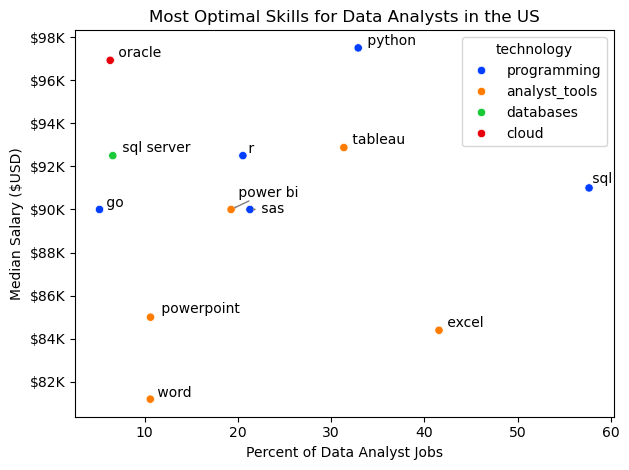

In [11]:
from adjustText import adjust_text

sns.scatterplot(data=df_skills_tech_high_demand, x='skill_percent', y='median_salary',
                hue='technology',  # Color by technology
                palette='bright',  # Use a bright palette for distinct colors
                legend='full') # Ensure the legend is shown

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_skills_high_demand.index):
    texts.append(plt.text(df_skills_high_demand['skill_percent'].iloc[i], df_skills_high_demand['median_salary'].iloc[i], " " + txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')
# plt.ylim(0,120000)
plt.title('Most Optimal Skills for Data Analysts in the US')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis

# Adjust layout and display plot 
plt.tight_layout()
plt.show()